In [4]:
import numpy as np
import pandas as pd

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(
    '../datasets/nutriscore_donnees_propres_final.csv',
    sep=';',
    encoding='utf-8'
)
df

C:\Users\loicq\AppData\Local\Temp\ipykernel_2004\1791469403.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code,product_name,nutriscore_score,nutriscore_grade,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g,fruits-vegetables-legumes_100g
0,112302621,Potiron et vermicelles,3,c,en:cream-of-pumpkin-soups,109.6,0.4,0.2,4.5,1.7,0.80000,0.7,0.280,28.781250
1,112302650,Délice de potiron châtaigne,3,c,en:pumpkin-soups,143.0,0.8,0.4,5.5,2.3,1.10000,0.7,0.304,31.666667
2,112302656,Lié big purSoup mouliné de 10 Légumes,3,c,en:vegetable-soups,150.0,1.2,0.4,4.6,1.4,1.50000,0.9,0.280,24.750000
3,112302660,Soupe potiron et kiri,3,c,en:vegetable-soups,161.0,1.5,1.0,4.9,2.0,0.80000,0.9,0.296,34.312500
4,112302676,Velouté de légumes du soleil,3,c,en:canned-vegetable-soups,147.5,1.7,0.3,3.7,1.4,0.80000,0.9,0.268,29.301250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148839,9876000000064,Chocolat Vegan Amandes Caramel Salé Équitable Bio,36,e,en:plant-milk-chocolates,2267.0,35.0,20.0,55.0,41.0,2.80000,3.0,0.792,0.000000
148840,9898909057345,Pão de Fôrma 35% Integral - Visconti - 400g,3,c,en:wholemeal-sliced-breads,593.5,2.1,0.6,25.0,6.0,2.00000,4.4,0.188,0.000000
148841,990530101020365169,Gâche tranchée,11,d,fr:gaches,931.8,8.0,5.4,32.0,8.7,3.75475,5.4,0.268,0.000000
148842,990530101025174626,Mon haché burger 100% pur boeuf,6,c,en:ground-beef-steaks,775.5,12.0,5.4,0.5,0.5,0.00000,19.0,0.088,0.000000


In [6]:
cols = [0,2,5,6,7]
df.iloc[:, cols] = df.iloc[:, cols].apply(pd.to_numeric, errors='coerce')

In [7]:
target = "nutriscore_grade"

df = df.dropna(subset=[target])
df = df[df["nutriscore_grade"] != "Italy"]
X = df.drop(columns=[target])
y = df[target]

# XGBoost ne gère pas nativement les variables catégorielles
# => encodage ordinal pour les colonnes object
cat_cols = X.select_dtypes(include='object').columns.tolist()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# Encodage de la cible (XGBoost attend des entiers de 0 à n_classes-1)
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

In [8]:
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='merror',       # merror = 1 - accuracy
    random_state=42,
    verbosity=1,
    early_stopping_rounds=50    # équivalent use_best_model de CatBoost
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-merror:0.73445	validation_1-merror:0.73446
[100]	validation_0-merror:0.01098	validation_1-merror:0.01199
[200]	validation_0-merror:0.00730	validation_1-merror:0.00897
[300]	validation_0-merror:0.00483	validation_1-merror:0.00779
[400]	validation_0-merror:0.00311	validation_1-merror:0.00705
[499]	validation_0-merror:0.00200	validation_1-merror:0.00675


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'merror'


In [9]:
# Nombre d'arbres effectivement utilisés (avec early stopping)
model.best_iteration

488

In [10]:
y_pred = model.predict(X_test)

# Reconversion des labels entiers en grades originaux
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

print("Accuracy :", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

Accuracy : 0.9932816016661628
              precision    recall  f1-score   support

           a       0.98      0.99      0.98      5285
           b       0.99      0.97      0.98      3612
           c       1.00      1.00      1.00      7905
           d       1.00      1.00      1.00      6719
           e       1.00      1.00      1.00      6248

    accuracy                           0.99     29769
   macro avg       0.99      0.99      0.99     29769
weighted avg       0.99      0.99      0.99     29769



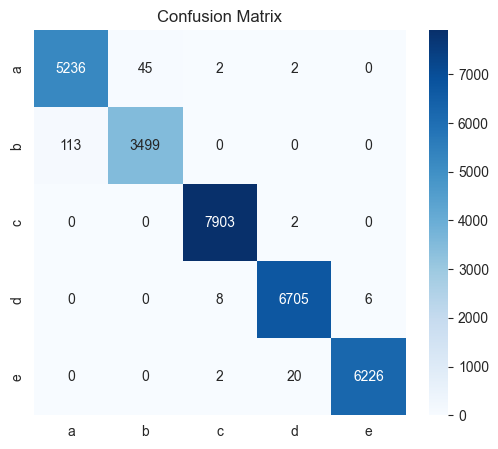

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(
    confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix')
plt.show()

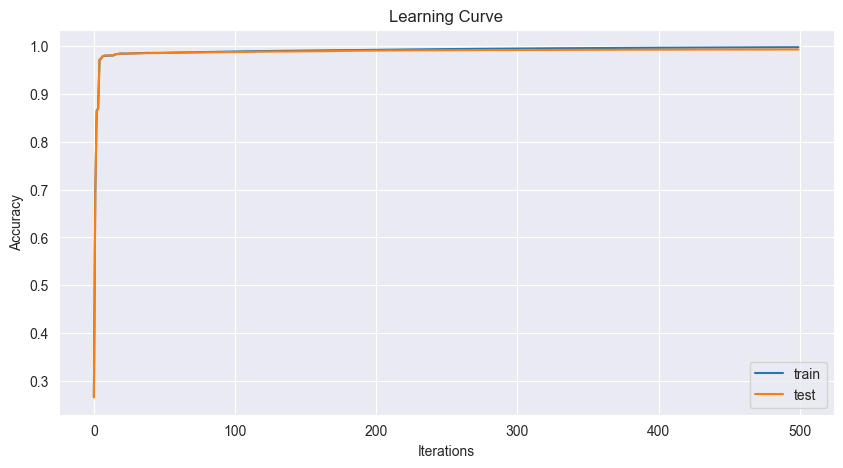

In [12]:
results = model.evals_result()

# merror = 1 - accuracy => conversion
train_acc = [1 - v for v in results['validation_0']['merror']]
test_acc  = [1 - v for v in results['validation_1']['merror']]

plt.figure(figsize=(10,5))
plt.plot(train_acc, label='train')
plt.plot(test_acc,  label='test')
plt.legend()
plt.title('Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.show()

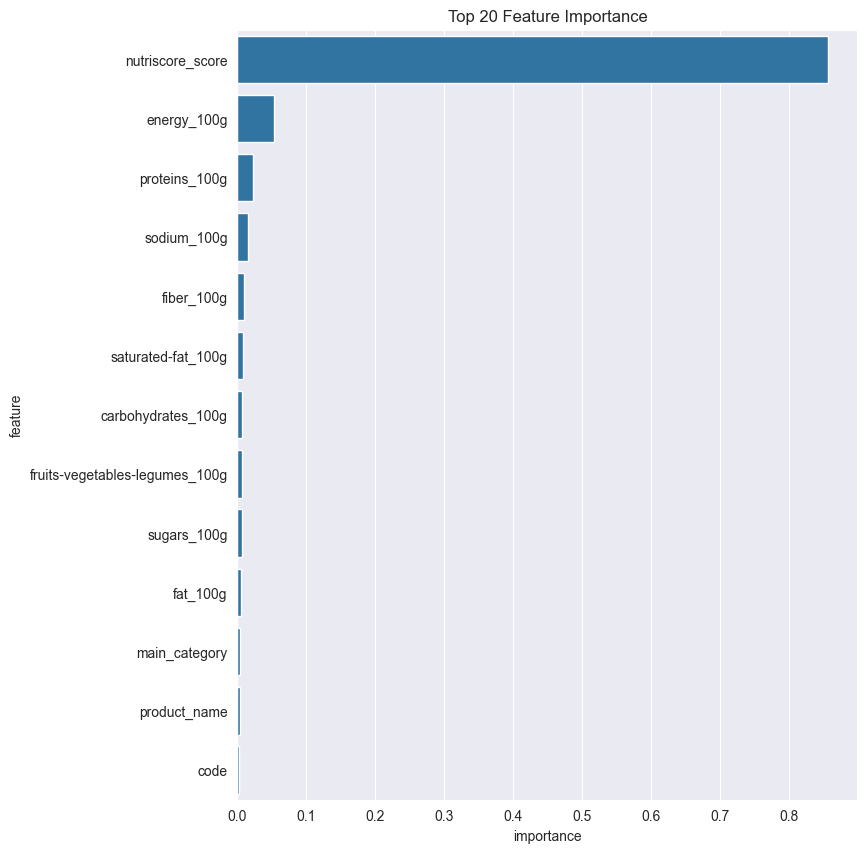

In [13]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.show()